## 2.2
Consider the dataset `Ames`. Split the dataset in training and test subset, fit a linear regressive model with a arbitrarily chosen output (usually `Sale_Price`) and estimate the test error. Analyse the trend of test error when training and test set are split in different proportions. You may drop the categorical variables for simplicity, if you wish.

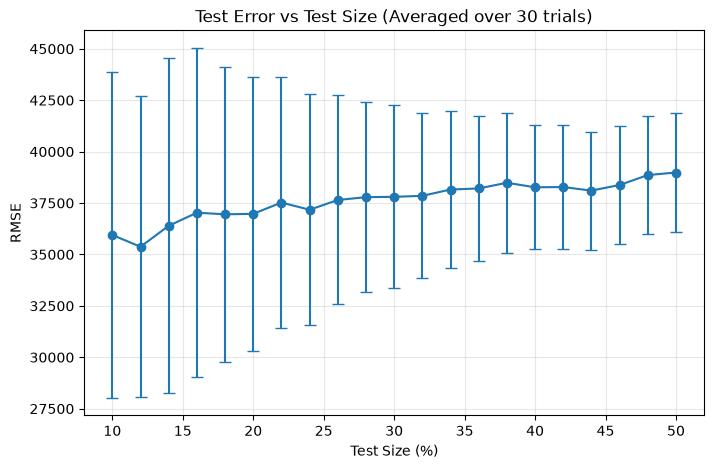

In [31]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error as mse
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Import the dataset Ames
df = fetch_openml(data_id=43926, as_frame=True)

# Keep only numeric features
X = df.data.select_dtypes(include='number').copy()
y = df.target

# Fit a linear regression model with imputation for missing values
model = make_pipeline(SimpleImputer(strategy='median'), LinearRegression())

# Analyse the trend of test error when training and test set are split in different proportions
test_sizes = np.linspace(0.1, 0.5, 21)

# Computes the average test error over multiple random splits to ensure a stable trend.
def compute_test_error(test_size, n_trials=30):
    errors = []
    # Loop to create 'n_trials' different random splits
    for seed in range(n_trials):
        # Change the random_state each loop iteration to get different splits
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=seed
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Calculate the Root Mean Squared Error (RMSE) and append to errors list
        errors.append(np.sqrt(mse(y_test, y_pred)))
    return np.mean(errors), np.std(errors)

results = [compute_test_error(ts) for ts in test_sizes]
mean_errors = [res[0] for res in results]
std_errors = [res[1] for res in results]

# Plot the test errors with error bars
plt.figure(figsize=(8, 5))
plt.errorbar(test_sizes * 100, mean_errors, yerr=std_errors, marker='o', capsize=4)
plt.xlabel('Test Size (%)')
plt.ylabel('RMSE')
plt.title('Test Error vs Test Size (Averaged over 30 trials)')
plt.grid(alpha=0.3)
plt.show()

## 2.3
Generate data, with polynomial dependence and perturbed by noise. Develop structured risk minimization to identify the optimal degree, in both cases of uniform and non-uniform weights.

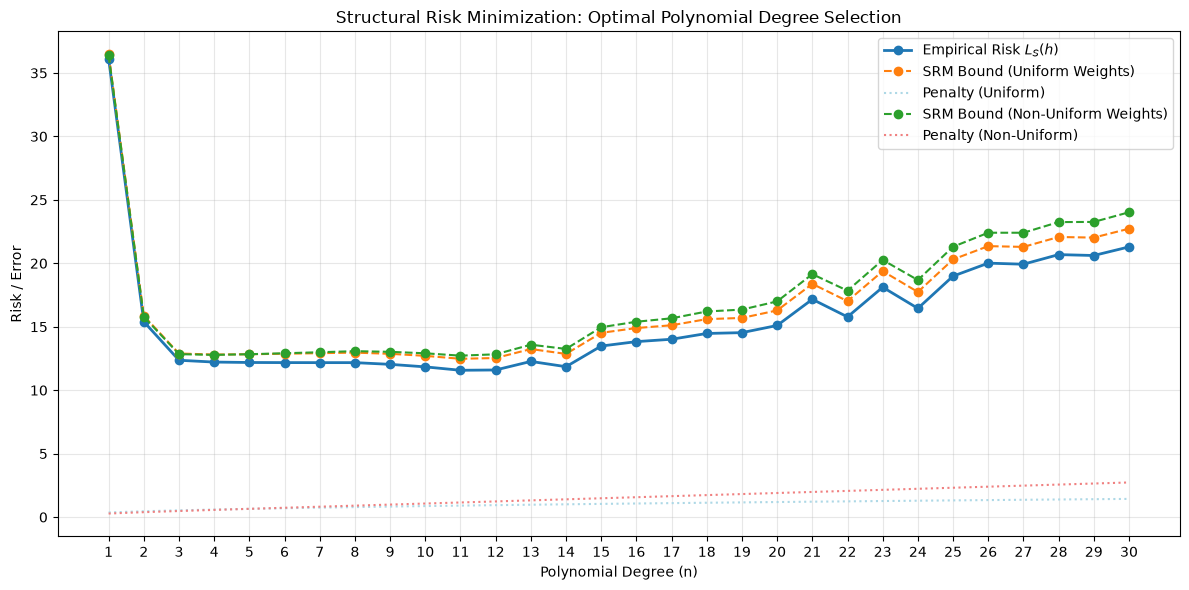

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Generate Data
np.random.seed(42)
m = 100
X = np.random.uniform(-3, 3, m)

y_true = 1 - 2 * X + 1.5 * (X ** 2) + 0.5 * (X ** 3)
noise = np.random.normal(0, 4, m)
y = y_true + noise

# Define SRM Parameters
N_max = 30
degrees = np.arange(1, N_max + 1)
delta = 0.05

# Define the weight functions
w_uniform = np.ones(N_max) / N_max
w_nonuniform = 2.0 ** (-degrees)

# Computes a standard generalization bound penalty proxy. d = n + 1 (number of parameters for a polynomial of degree n)
def compute_complexity_penalty(d, m, delta):
    return np.sqrt(((d + 1) * np.log(1/delta) + 2 * np.log(d) + np.log(np.pi ** 2 / 6)) / m)

# Fit Models and Calculate Risks
empirical_risks = []

for n in degrees:
    # Transform features to polynomial
    poly = PolynomialFeatures(degree=n, include_bias=False)
    X_poly = poly.fit_transform(X.reshape(-1, 1))
    
    # Fit model and calculate Empirical Risk (L_S(h))
    model = LinearRegression().fit(X_poly, y)
    y_pred = model.predict(X_poly)
    empirical_risks.append(mean_squared_error(y, y_pred))

empirical_risks = np.array(empirical_risks)

# Calculate SRM Bounds
# # We scale the penalties slightly just to make them visually comparable to MSE on the same plot
# scaling_factor = 10 

penalties_uniform = np.array([
    compute_complexity_penalty(n, m, delta * w_uniform[i]) for i, n in enumerate(degrees)
]) 

penalties_nonuniform = np.array([
    compute_complexity_penalty(n, m, delta * w_nonuniform[i]) for i, n in enumerate(degrees)
])

# Total SRM Bound = L_S(h) + Penalty
srm_uniform = empirical_risks + penalties_uniform
srm_nonuniform = empirical_risks + penalties_nonuniform

# # Identify optimal degrees
# opt_deg_uni = degrees[np.argmin(srm_uniform)]
# opt_deg_non = degrees[np.argmin(srm_nonuniform)]

# 5. Visualization
plt.figure(figsize=(12, 6))

# Plot Empirical Risk
plt.plot(degrees, empirical_risks, label='Empirical Risk $L_S(h)$', marker='o', linewidth=2)

# Plot Uniform Weighting SRM
plt.plot(degrees, srm_uniform, label=f'SRM Bound (Uniform Weights)', linestyle='--', marker='o')
plt.plot(degrees, penalties_uniform, label='Penalty (Uniform)', linestyle=':', color='lightblue')
# plt.axvline(opt_deg_uni, color='blue', alpha=0.3, label=f'Optimum Uniform (Degree {opt_deg_uni})')

# Plot Non-Uniform Weighting SRM
plt.plot(degrees, srm_nonuniform, label=f'SRM Bound (Non-Uniform Weights)', linestyle='--', marker='o')
plt.plot(degrees, penalties_nonuniform, label='Penalty (Non-Uniform)', linestyle=':', color='lightcoral')
# plt.axvline(opt_deg_non, color='red', alpha=0.3, label=f'Optimum Non-Uniform (Degree {opt_deg_non})')

plt.title('Structural Risk Minimization: Optimal Polynomial Degree Selection')
plt.xlabel('Polynomial Degree (n)')
plt.ylabel('Risk / Error')
plt.xticks(degrees)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.5
Generate a dataset, apply a prediction technique (linear regression or $k$-nearest-neighbour, for instance) to evaluate statistically the test error. Evaluate the theoretical error (empirical mean and standard deviation). Evaluate the error through hold out set validation, LOO-CV and $k$-fold CV (empirical mean and standard deviation). Evaluate in particular the test error trend for different values of $k$.

Theoretical test error: mean=0.5363, std=0.0120
Repeated holdout error: mean=0.5594, std=0.0697
LOO-CV error: mean=0.5612, std=0.5094
Best k-fold setting: 6 folds


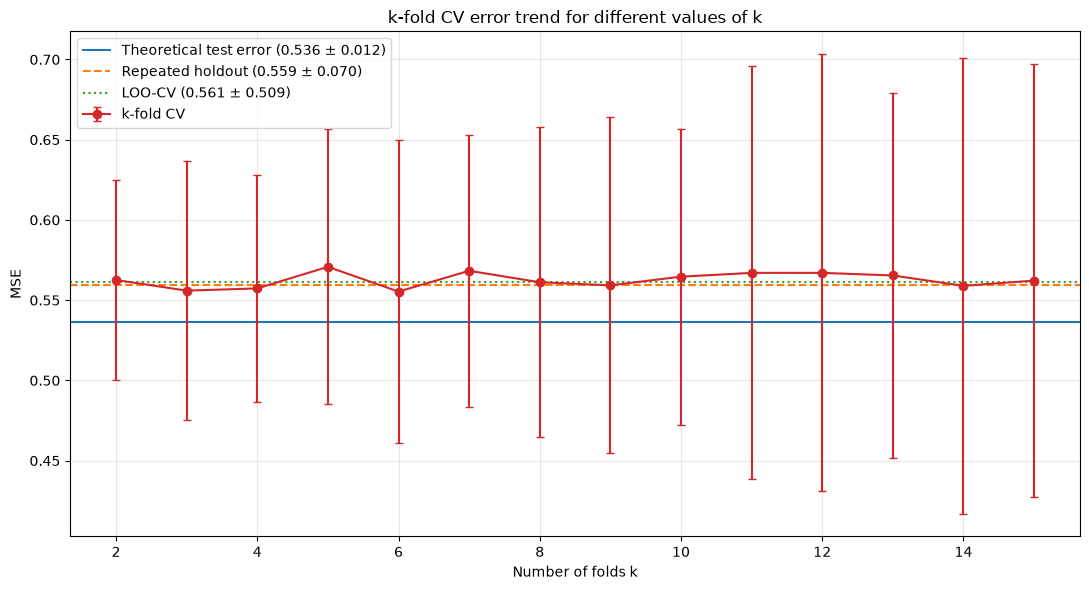

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_score, train_test_split

RANDOM_SEED = 42
NOISE_STD = 0.25
N_SAMPLES = 120
TEST_FRACTION = 0.3
N_MONTE_CARLO = 120
N_HOLDOUT_REPEATS = 50
FOLD_VALUES = np.arange(2, 16)


def true_function(x):
    return np.sin(2 * np.pi * x) + 0.5 * x


def generate_dataset(n_samples, seed):
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1.5, 1.5, size=(n_samples, 1))
    y = true_function(x[:, 0]) + rng.normal(0.0, NOISE_STD, size=n_samples)
    return x, y


def fit_model(x_train, y_train):
    model = LinearRegression()
    model.fit(x_train, y_train)
    return model


def estimate_theoretical_test_error(n_repeats=N_MONTE_CARLO):
    errors = []
    rng = np.random.default_rng(RANDOM_SEED + 1000)

    for _ in range(n_repeats):
        train_seed = int(rng.integers(0, 1_000_000_000))
        test_seed = int(rng.integers(0, 1_000_000_000))
        x_train, y_train = generate_dataset(N_SAMPLES, train_seed)
        x_test, y_test = generate_dataset(5000, test_seed)
        model = fit_model(x_train, y_train)
        errors.append(mean_squared_error(y_test, model.predict(x_test)))

    errors = np.asarray(errors)
    return errors.mean(), errors.std()


def estimate_holdout_error(n_repeats=N_HOLDOUT_REPEATS, test_size=TEST_FRACTION):
    rng = np.random.default_rng(RANDOM_SEED + 2000)
    x, y = generate_dataset(N_SAMPLES, RANDOM_SEED)
    errors = []

    for _ in range(n_repeats):
        split_seed = int(rng.integers(0, 1_000_000_000))
        x_train, x_test, y_train, y_test = train_test_split(
            x, y, test_size=test_size, random_state=split_seed
        )
        model = fit_model(x_train, y_train)
        errors.append(mean_squared_error(y_test, model.predict(x_test)))

    errors = np.asarray(errors)
    return errors.mean(), errors.std()


def estimate_loocv_error():
    x, y = generate_dataset(N_SAMPLES, RANDOM_SEED)
    scores = cross_val_score(
        LinearRegression(),
        x,
        y,
        scoring="neg_mean_squared_error",
        cv=LeaveOneOut(),
        n_jobs=-1,
    )
    errors = -scores
    return errors.mean(), errors.std()


def estimate_kfold_error(n_splits):
    x, y = generate_dataset(N_SAMPLES, RANDOM_SEED)
    scores = cross_val_score(
        LinearRegression(),
        x,
        y,
        scoring="neg_mean_squared_error",
        cv=KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED),
        n_jobs=-1,
    )
    errors = -scores
    return errors.mean(), errors.std()


theoretical_mean, theoretical_std = estimate_theoretical_test_error()
holdout_mean, holdout_std = estimate_holdout_error()
loo_mean, loo_std = estimate_loocv_error()

kfold_mean = []
kfold_std = []

for n_splits in FOLD_VALUES:
    c_mean, c_std = estimate_kfold_error(n_splits)
    kfold_mean.append(c_mean)
    kfold_std.append(c_std)

kfold_mean = np.asarray(kfold_mean)
kfold_std = np.asarray(kfold_std)

best_fold = FOLD_VALUES[np.argmin(kfold_mean)]

print(f"Theoretical test error: mean={theoretical_mean:.4f}, std={theoretical_std:.4f}")
print(f"Repeated holdout error: mean={holdout_mean:.4f}, std={holdout_std:.4f}")
print(f"LOO-CV error: mean={loo_mean:.4f}, std={loo_std:.4f}")
print(f"Best k-fold setting: {best_fold} folds")

plt.figure(figsize=(11, 6))
plt.axhline(
    theoretical_mean,
    color="tab:blue",
    linestyle="-",
    label=f"Theoretical test error ({theoretical_mean:.3f} ± {theoretical_std:.3f})",
)
plt.axhline(
    holdout_mean,
    color="tab:orange",
    linestyle="--",
    label=f"Repeated holdout ({holdout_mean:.3f} ± {holdout_std:.3f})",
)
plt.axhline(
    loo_mean,
    color="tab:green",
    linestyle=":",
    label=f"LOO-CV ({loo_mean:.3f} ± {loo_std:.3f})",
)
plt.errorbar(
    FOLD_VALUES,
    kfold_mean,
    yerr=kfold_std,
    marker="o",
    capsize=3,
    color="tab:red",
    label="k-fold CV",
)
plt.xlabel("Number of folds k")
plt.ylabel("MSE")
plt.title("k-fold CV error trend for different values of k")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()